確認notebook python環境

In [1]:
import sys

print(sys.executable)

/opt/anaconda3/envs/medical-ai/bin/python


安裝NiBabel影像套件，用於讀取NIfTI格式的工具（用Terminal安裝）
notebook測試，輸出版本5.4.2

In [2]:
import nibabel as nib

print(nib.__version__)

5.4.2


新增第一個正式的醫學影像程式（下載一個公開）fmri資料
目前學習的路徑是NIfTI>python>三維影像
下一階段：BraTS>腦腫瘤segementation>MONAI>AI model
現在這步已經完成用python讀取NIfTI format

In [3]:
from nilearn import datasets

data = datasets.fetch_development_fmri(n_subjects=1)

print(data)

[fetch_development_fmri] Added README.md to /Users/liaoyubo/nilearn_data
[fetch_development_fmri] Dataset created in /Users/liaoyubo/nilearn_data/development_fmri
[fetch_development_fmri] Added README.md to /Users/liaoyubo/nilearn_data/development_fmri
[fetch_development_fmri] Dataset created in /Users/liaoyubo/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Downloading data from https://osf.io/yr3av/download ...
[fetch_development_fmri]  ...done. (4 seconds, 0 min)

[fetch_development_fmri] Dataset directory found: /Users/liaoyubo/nilearn_data/development_fmri/development_fmri
[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3df4712b400183b7092/ ...
[fetch_development_fmri]  ...done. (3 seconds, 0 min)

[fetch_development_fmri] Downloading data from https://osf.io/download/5c8ff3e04712b400193b5bdf/ ...
Downloaded 344064 of 5642698 bytes (6.1%%, 00 HR 00 MIN 16 SEC remaining)
[fetch_development_fmri]  ...done. (4 seconds, 0 min)

{'fun

使用NiBabel讀取mri影像
取得mri路徑

In [4]:
import nibabel as nib
data.func[0]
mri_path = data.func[0]

print(mri_path)

/Users/liaoyubo/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz


載入NIfTi影像

In [5]:
img = nib.load(mri_path)

print(img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (50, 59, 50, 168)
affine:
[[   4.    0.    0.  -96.]
 [   0.    4.    0. -132.]
 [   0.    0.    4.  -78.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [  4  50  59  50 168   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 4. 4. 4. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 0
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b''
aux_file        : b''
qform_code      : unknown
sform_code      : align

In [ ]:
查看mri資料大小（x,y,z,time）

In [6]:
img.shape

(50, 59, 50, 168)

取得影像矩陣
mri已轉成NumPy array
ai模型是吃NumPy array/Tensor

In [7]:
mri_data = img.get_fdata()

print(type(mri_data))
print(mri_data.shape)

<class 'numpy.ndarray'>
(50, 59, 50, 168)


視覺化mri
mri_data[:,:,:,0] #第0個時間點的三維腦部影像

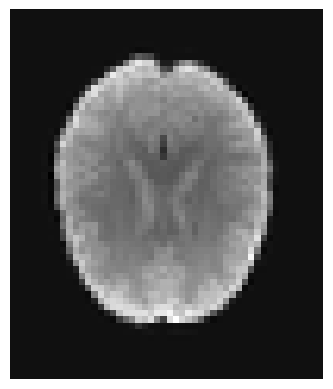

In [8]:
import matplotlib.pyplot as plt

# 取第0個時間點
slice_img = mri_data[:, :, :, 0]

# 取中間切片
middle_slice = slice_img[:, :, 25]

plt.imshow(middle_slice.T, cmap="gray")
plt.axis("off")
plt.show()

In [9]:
print(mri_data.min())
print(mri_data.max())
print(mri_data.mean())

-127.6077880859375
1345.5571112632751
93.07971777885463


做z-score normalization>>mean=0,std=1

In [10]:
import numpy as np

mri_normalized = (
    mri_data - np.mean(mri_data)
) / np.std(mri_data)


print(mri_normalized.min())
print(mri_normalized.max())
print(mri_normalized.mean())

-1.0155142896428695
5.763392383968216
-3.127076214328228e-17


In [11]:
import monai

print(monai.__version__)

1.6.0
